# Bays (2014) Figure 5 — Baseline Effects on Gain, Width, SNR

**Key insight**: Adding baseline activity requires a compensating increase in
gain to maintain the same error distributions. The SNR remains approximately constant.

**Method**: For each baseline fraction, we jointly fit (γ, ω) by matching the
single-item error variance to the zero-baseline reference. We report ω = λ²
(the Bays-equivalent tuning width) on all axes.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import logsumexp, i0, i1
from scipy.optimize import brentq
from scipy.stats import vonmises, gaussian_kde

from core.encoder.gaussian_process import (
    generate_neuron_population, periodic_rbf_kernel, sample_gp_function,
)
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes

print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


In [2]:
# Circular statistics + ML decoder
from scipy.special import i0, i1
from scipy.optimize import brentq
from scipy.stats import vonmises

def compute_log_likelihood(counts, g, T_d):
    log_g = np.log(np.maximum(g, 1e-30))
    return counts @ log_g - T_d * np.sum(g, axis=0)

def compute_circular_error(theta_true, theta_hat):
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

def circular_variance(errors):
    return 1.0 - np.abs(np.mean(np.exp(1j * errors)))

def circular_kurtosis(errors):
    """Fisher (1995) / Bays (2014) circular kurtosis."""
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    if V < 1e-10:
        return 0.0
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    return (rho2 * phase_correction - rho1**4) / max(V**2, 1e-15)

def _estimate_von_mises_kappa(rho1):
    """ML estimate of von Mises kappa from mean resultant length."""
    if rho1 < 1e-6: return 0.0
    if rho1 > 0.9999: return 700.0
    return brentq(lambda k: float(i1(k)/i0(k)) - rho1, 1e-4, 700.0)

def compute_deviation_from_normal(errors, n_bins=50):
    """Empirical histogram minus best-fit von Mises."""
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    kappa_fit = _estimate_von_mises_kappa(rho1)
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp,
            'normal_fit': vm_pdf, 'deviation': emp - vm_pdf,
            'kappa': kappa_fit, 'variance': 1.0 - rho1}

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================
M = 100; N_THETA = 128; T_D = 0.1; SIGMA_SQ = 1e-6

# Reference parameters: omega = 1/lambda
OMEGA_REF = 0.52                    # Bays group-mean tuning width
LAMBDA_REF = 1.0 / OMEGA_REF        # = 1.92
GAMMA_REF_TOTAL = 119.0             # Bays total subpop gain (Hz)

SET_SIZES = [1, 2, 4, 8]
BASELINE_FRACS = [0.0, 0.05, 0.20, 0.50, 0.80]

N_TRIALS_FIT = 2000
N_TRIALS_FINAL = 5000
SEED = 42

print(f'Config: M={M}, N_THETA={N_THETA}')
print(f'omega_ref={OMEGA_REF} (lambda={LAMBDA_REF:.3f})')
print(f'gamma_ref_total={GAMMA_REF_TOTAL} Hz')


Config: M=100, N_THETA=128
omega_ref=0.52 (lambda=1.923)
gamma_ref_total=119.0 Hz


## Population generation with baseline

In [4]:
def periodic_rbf_kernel(thetas, lengthscale):
    diff = thetas[:, None] - thetas[None, :]
    return np.exp(-2.0 * np.sin(diff / 2.0)**2 / lengthscale**2)

def sample_gp_function(K, rng):
    n = K.shape[0]
    L = np.linalg.cholesky(K + 1e-8 * np.eye(n))
    return L @ rng.randn(n)

def gen_pop_baseline(M, n_theta, lengthscale, baseline_frac, seed):
    """Generate GP population with additive baseline (Bays Eq. 14).
    g_i(theta) = exp(f_i(theta)) + f0
    where f0/(f0+1) = baseline_frac."""
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    K = periodic_rbf_kernel(thetas, lengthscale)
    g_raw = np.zeros((M, n_theta))
    for i in range(M):
        g_raw[i] = np.exp(sample_gp_function(K, rng))
    if baseline_frac < 1e-10:
        return thetas, g_raw
    mean_peak = np.mean(np.max(g_raw, axis=1))
    f0 = baseline_frac * mean_peak / (1.0 - baseline_frac)
    return thetas, g_raw + f0

def run_trials_single_item(g, thetas, gamma_total, T_d, sigma_sq, n_trials, rng):
    """Encode + decode a single item.
    DN: r_i = (gamma_total/M) * g_i / (sigma_sq + mean(g))."""
    M_pop, n_theta = g.shape
    log_g = np.log(np.maximum(g, 1e-30))
    T_d_sum_g = T_d * np.sum(g, axis=0)
    errors = np.empty(n_trials)
    for t in range(n_trials):
        idx = rng.randint(n_theta)
        D = sigma_sq + np.mean(g[:, idx])
        rates = (gamma_total / M_pop) * g[:, idx] / D
        counts = rng.poisson(np.maximum(rates * T_d, 0.0))
        ll = counts @ log_g - T_d_sum_g
        errors[t] = compute_circular_error(thetas[idx], thetas[np.argmax(ll)])
    return errors

def compute_snr_analytic(g, gamma_total, M, T_d, sigma_sq):
    """Bays Eq. 15-16: per-neuron SNR.
    SNR = T_d * Var_theta[r(theta)] / E_theta[r(theta)]
    This measures how much the rate varies with stimulus relative
    to its Poisson noise level."""
    M_pop, n_theta = g.shape
    # Compute rates at each orientation
    mean_g_per_theta = np.mean(g, axis=0)  # (n_theta,)
    denom = sigma_sq + mean_g_per_theta
    rates = (gamma_total / M_pop) * g / denom[np.newaxis, :]  # (M, n_theta)
    # Per-neuron SNR
    E_r = np.mean(rates, axis=1)       # mean rate over theta
    E_r2 = np.mean(rates**2, axis=1)   # mean squared rate
    Var_r = E_r2 - E_r**2              # variance of rate
    snr_per_neuron = T_d * Var_r / np.maximum(E_r, 1e-15)
    return np.mean(snr_per_neuron)


## Phase 1: Reference + Phase 2: Sweep baselines

In [5]:
t0 = time.time()

# Step 1: Reference variance (zero baseline, single item)
thetas_ref, g_ref = gen_pop_baseline(M, N_THETA, LAMBDA_REF, 0.0, SEED)
rng_ref = np.random.RandomState(SEED + 999)
errs_ref = run_trials_single_item(g_ref, thetas_ref, GAMMA_REF_TOTAL,
                                   T_D, SIGMA_SQ, N_TRIALS_FIT, rng_ref)
target_var = circular_variance(errs_ref)
print(f'Reference: gamma={GAMMA_REF_TOTAL:.1f} Hz, omega={OMEGA_REF:.2f}, var={target_var:.4f}')

# Step 2: For each baseline, search ONLY over gamma (lambda stays fixed)
# Bays Fig 5b shows omega is approximately constant — he does not refit it.
# Only gamma needs to increase to compensate for the baseline diluting the signal.
gamma_grid = np.logspace(np.log10(50), np.log10(5e4), 50)

results = {}
for bf in BASELINE_FRACS:
    print(f'  Fitting baseline={bf*100:.0f}%...')
    thetas_b, g_b = gen_pop_baseline(M, N_THETA, LAMBDA_REF, bf, SEED)

    if bf < 1e-10:
        best_gamma = GAMMA_REF_TOTAL
    else:
        best_cost = np.inf
        best_gamma = GAMMA_REF_TOTAL
        for gam_try in gamma_grid:
            # Use MORE trials for stable variance estimate
            rng_try = np.random.RandomState(
                SEED + int(bf*1000) + int(np.log10(gam_try)*100))
            errs_try = run_trials_single_item(
                g_b, thetas_b, gam_try, T_D, SIGMA_SQ, 1000, rng_try)
            v = circular_variance(errs_try)
            cost = (np.log(max(v, 1e-10)) - np.log(max(target_var, 1e-10)))**2
            if cost < best_cost:
                best_cost = cost
                best_gamma = gam_try

    # Full simulation at best-fit gamma (lambda stays at LAMBDA_REF)
    snr = compute_snr_analytic(g_b, best_gamma, M, T_D, SIGMA_SQ)

    dists = {}
    for N in SET_SIZES:
        rng_n = np.random.RandomState(SEED + N + int(bf*10000))
        errs = run_trials_single_item(g_b, thetas_b, best_gamma / N,
                                      T_D, SIGMA_SQ, N_TRIALS_FINAL, rng_n)
        dists[N] = {'errors': errs, 'variance': circular_variance(errs)}

    results[bf] = {
        'gamma': best_gamma,
        'lambda': LAMBDA_REF,
        'omega': 1.0 / LAMBDA_REF,  # constant since lambda is fixed
        'snr': snr,
        'dists': dists,
    }
    print(f'    -> gamma={best_gamma:.1f} Hz, omega={1.0/LAMBDA_REF:.3f}, snr={snr:.4f}')

print(f'Done in {time.time()-t0:.1f}s')


Reference: gamma=119.0 Hz, omega=0.52, var=0.2568
  Fitting baseline=0%...
    -> gamma=119.0 Hz, omega=0.520, snr=0.0300
  Fitting baseline=5%...
    -> gamma=154.4 Hz, omega=0.520, snr=0.0335
  Fitting baseline=20%...
    -> gamma=204.7 Hz, omega=0.520, snr=0.0287
  Fitting baseline=50%...
    -> gamma=7999.3 Hz, omega=0.520, snr=0.4147
  Fitting baseline=80%...
    -> gamma=6947.5 Hz, omega=0.520, snr=0.0650
Done in 14.2s


## Plot: 2x2 panels

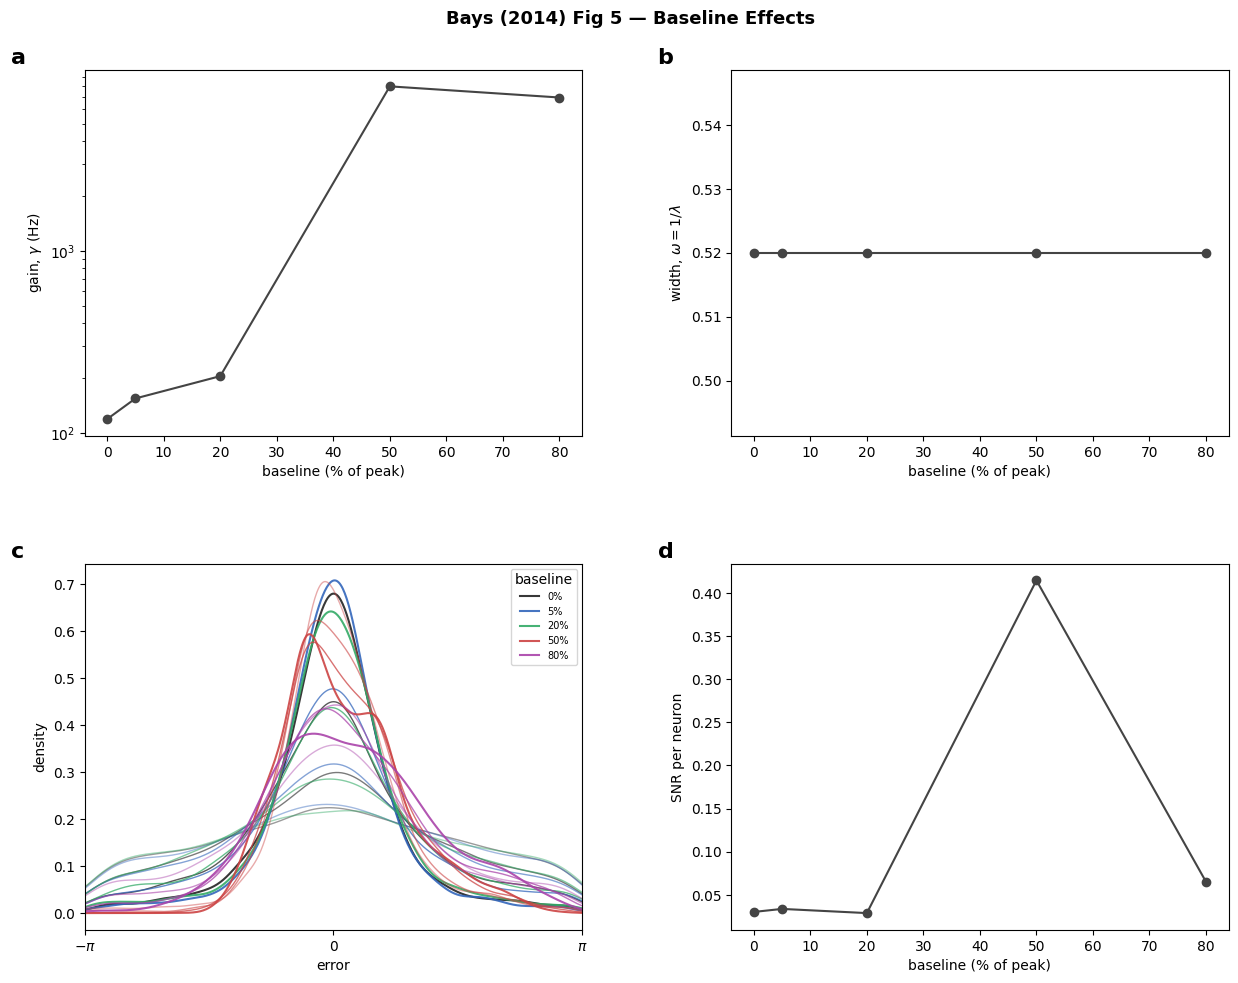

In [6]:
GREY = '#444444'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.30,
                       left=0.08, right=0.96, bottom=0.06, top=0.92)
x_pct = [bf * 100 for bf in BASELINE_FRACS]

# === Panel a: fitted gamma vs baseline (log scale) ===
ax_a = fig.add_subplot(gs[0, 0])
gammas_fitted = [results[bf]['gamma'] for bf in BASELINE_FRACS]
ax_a.semilogy(x_pct, gammas_fitted, 'o-', color=GREY, lw=1.5, ms=6)
ax_a.set_xlabel('baseline (% of peak)')
ax_a.set_ylabel(r'gain, $\gamma$ (Hz)')
ax_a.text(-0.15, 1.06, r'$\mathbf{a}$', transform=ax_a.transAxes,
          fontsize=16, fontweight='bold', va='top')

# === Panel b: fitted omega vs baseline ===
ax_b = fig.add_subplot(gs[0, 1])
omegas_fitted = [results[bf]['omega'] for bf in BASELINE_FRACS]
ax_b.plot(x_pct, omegas_fitted, 'o-', color=GREY, lw=1.5, ms=6)
ax_b.set_xlabel('baseline (% of peak)')
ax_b.set_ylabel(r'width, $\omega = 1/\lambda$')
ax_b.text(-0.15, 1.06, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=16, fontweight='bold', va='top')

# === Panel c: error distributions (KDE, all set sizes per baseline) ===
ax_c = fig.add_subplot(gs[1, 0])
colors_c = ['#222222', '#3366BB', '#33AA66', '#CC4444', '#AA44AA']
for bi, bf in enumerate(BASELINE_FRACS):
    c = colors_c[bi % len(colors_c)]
    label = f'{bf*100:.0f}%'
    for ni, N in enumerate(SET_SIZES):
        errs = results[bf]['dists'][N]['errors']
        try:
            kde = gaussian_kde(errs, bw_method=0.2)
            curve = kde(theta_smooth)
        except Exception:
            continue
        lw = 1.5 if ni == 0 else 1.0
        alpha = 0.9 - 0.15 * ni
        ax_c.plot(theta_smooth, curve, color=c, lw=lw, alpha=alpha,
                  label=label if ni == 0 else None)
ax_c.set_xlim(-np.pi, np.pi)
ax_c.set_xticks([-np.pi, 0, np.pi])
ax_c.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
ax_c.set_xlabel('error'); ax_c.set_ylabel('density')
ax_c.legend(fontsize=7, title='baseline', loc='upper right')
ax_c.text(-0.15, 1.06, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=16, fontweight='bold', va='top')

# === Panel d: SNR vs baseline ===
ax_d = fig.add_subplot(gs[1, 1])
snrs = [results[bf]['snr'] for bf in BASELINE_FRACS]
ax_d.plot(x_pct, snrs, 'o-', color=GREY, lw=1.5, ms=6)
ax_d.set_xlabel('baseline (% of peak)')
ax_d.set_ylabel('SNR per neuron')
ax_d.text(-0.15, 1.06, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=16, fontweight='bold', va='top')

fig.suptitle('Bays (2014) Fig 5 \u2014 Baseline Effects',
             fontsize=13, fontweight='bold')
plt.savefig('bays_fig5.png', dpi=150, bbox_inches='tight')
plt.show()
